# Explicit Runge-Kutta methods and their order of convergence

Every explicit Runge-Kutta method in `si.TABLEAUS`, and one written by hand, becomes a discrete map
through `si.explicit`, and runs on two problems until its global error shows its order: a linear
system with a matrix-exponential solution, and the Van der Pol oscillator against a tight
`solve_ivp`. The step size is an input of each map, so one compiled Function per method and problem
covers the whole step-size sweep.

Along the way the notebook prints the Butcher tableaus, draws the stability regions, checks
Butcher's order conditions with `si.order_conditions`, and shows why DOPRI5's observed order depends
on the problem more than the others do.

| Scaly feature | Where |
| --- | --- |
| `si.TABLEAUS`, `si.tableau` | The methods as Butcher tableaus |
| `si.Tableau`, `si.order_conditions` | A method of one's own |
| `si.explicit(model, method, dt=None)` | Observed orders |
| `si.rk4` with the interval folded in, `write_module` | The generated C |

In [1]:
import sys
from fractions import Fraction
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from scipy.linalg import expm

sys.path.insert(0, str(Path.cwd().parent / "notebooks"))  # the shared plot style
import plotstyle
import scaly as sc
from scaly import integrators as si
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "integrators" / "explicit_methods"

## The methods as Butcher tableaus

An $s$-stage Runge-Kutta method takes a step $h$ on $x' = f(x)$ as

$$
k_i = f\Big(x + h \sum_{j=1}^{s} a_{ij} k_j\Big), \qquad x_{\text{next}} = x + h \sum_{i=1}^{s} b_i k_i ,
$$

where stage $i$ sits at time $t + c_i h$ and $c_i = \sum_j a_{ij}$. The method is explicit when $A$
is strictly lower triangular, so that each stage reads only the ones before it. `si.TABLEAUS` holds
the implicit methods too; the explicit ones are those with `tab.explicit`.

In [2]:
explicit = [name for name, tab in si.TABLEAUS.items() if tab.explicit]
print(f"{'method':>9} {'stages':>6} {'order':>5}   nodes c")
for name in explicit:
  tab = si.TABLEAUS[name]
  print(f"{name:>9} {tab.stages:>6} {tab.order:>5}   {np.array2string(tab.c, precision=3)}")

   method stages order   nodes c
    euler      1     1   [0.]
     heun      2     2   [0. 1.]
 midpoint      2     2   [0.  0.5]
  ralston      2     2   [0.    0.667]
      rk3      3     3   [0.  0.5 1. ]
   ssprk3      3     3   [0.  1.  0.5]
      rk4      4     4   [0.  0.5 0.5 1. ]
     rk38      4     4   [0.    0.333 0.667 1.   ]
     bs32      4     3   [0.   0.5  0.75 1.  ]
   dopri5      7     5   [0.    0.2   0.3   0.8   0.889 1.    1.   ]


Two of them with their coefficients as fractions: the classical RK4, and Bogacki-Shampine 3(2),
whose last row `b_err` holds the weights of the embedded second-order solution. The last stage of
`bs32` evaluates the model at the new point. The step gives it weight 0: it serves only the error
estimate, and in an adaptive integrator the next step's first stage. So the map drops it and calls
the model three times per step.

In [3]:
def fraction(value: float) -> str:
  return str(Fraction(float(value)).limit_denominator(100_000))


def show(tab: si.Tableau) -> None:
  """Print the tableau as rows ``c_i | a_i1 .. a_is``, then ``| b``, and ``| b_err`` for a pair."""
  rows = [[fraction(c), *map(fraction, a)] for c, a in zip(tab.c, tab.a, strict=True)] + [["", *map(fraction, tab.b)]]
  if tab.b_err is not None:
    rows.append(["", *map(fraction, tab.b_err)])
  width = max(len(v) for row in rows for v in row)
  print(f"{tab.name}, order {tab.order}")
  for i, row in enumerate(rows):
    if i == tab.stages:
      print("-" * (width + 3 + (width + 1) * tab.stages))
    print(f"{row[0]:>{width}} | " + " ".join(f"{v:>{width}}" for v in row[1:]))
  print()


show(si.TABLEAUS["rk4"])
show(si.TABLEAUS["bs32"])

rk4, order 4
  0 |   0   0   0   0
1/2 | 1/2   0   0   0
1/2 |   0 1/2   0   0
  1 |   0   0   1   0
----------------------
    | 1/6 1/3 1/3 1/6

bs32, order 3
   0 |    0    0    0    0
 1/2 |  1/2    0    0    0
 3/4 |    0  3/4    0    0
   1 |  2/9  1/3  4/9    0
---------------------------
     |  2/9  1/3  4/9    0
     | 7/24  1/4  1/3  1/8



### Stability regions

On $x' = \lambda x$ one step multiplies $x$ by the stability function
$R(z) = 1 + z\, b^\top (I - zA)^{-1} \mathbf{1}$, with $z = h\lambda$. For an explicit method $A$ is
nilpotent, so $R(z) = 1 + \sum_{k=1}^{s} (b^\top A^{k-1} \mathbf{1})\, z^k$ is a polynomial of
degree at most $s$. A method of order $p$ matches $e^z$ through $z^p$, so for $p = s \le 4$ it is
exactly the Taylor polynomial $\sum_{k \le p} z^k / k!$. The step is stable where $|R(z)| \le 1$.

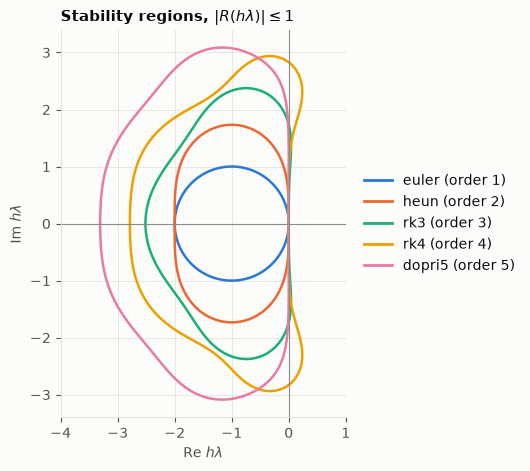

DOPRI5's R(z), z^5 and z^6: ['1/120', '1/600']   e^z's: ['1/120', '1/720']


In [4]:
def stability_polynomial(tab: si.Tableau) -> np.ndarray:
  """The coefficients of ``R(z)``, lowest degree first."""
  coefficients, power = [1.0], np.ones(tab.stages)
  for _ in range(tab.stages):
    coefficients.append(float(tab.b @ power))
    power = tab.a @ power
  return np.trim_zeros(np.array(coefficients), "b")


re, im = np.meshgrid(np.linspace(-5.0, 1.0, 400), np.linspace(-4.0, 4.0, 400))
z = re + 1j * im
fig, ax = plt.subplots(figsize=(7, 4.6))
for name, color in zip(("euler", "heun", "rk3", "rk4", "dopri5"), plotstyle.SERIES, strict=False):
  magnitude = np.abs(np.polynomial.polynomial.polyval(z, stability_polynomial(si.TABLEAUS[name])))
  ax.contour(re, im, magnitude, levels=[1.0], colors=[color], linewidths=1.8)
  ax.plot([], [], color=color, label=f"{name} (order {si.TABLEAUS[name].order})")
ax.axhline(0, color=plotstyle.NEUTRAL, lw=0.8)
ax.axvline(0, color=plotstyle.NEUTRAL, lw=0.8)
ax.set_aspect("equal")
ax.set_xlim(-4.0, 1.0)
ax.set_ylim(-3.4, 3.4)
ax.set_xlabel(r"Re $h\lambda$")
ax.set_ylabel(r"Im $h\lambda$")
ax.set_title(r"Stability regions, $|R(h\lambda)| \leq 1$")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.show()

dopri5 = stability_polynomial(si.TABLEAUS["dopri5"])
print("DOPRI5's R(z), z^5 and z^6:", [fraction(c) for c in dopri5[5:]], "  e^z's:", [fraction(1 / 120), fraction(1 / 720)])

The regions grow with the order, and DOPRI5's reaches out to $h\lambda \approx -3.3$ on the real
axis. Its stability polynomial has degree 6: it matches $e^z$ through $z^5$ and then has $z^6/600$
where $e^z$ has $z^6/720$. That extra term matters below, on the linear problem.

## A method of one's own

Heun's third-order method has the nodes $c = (0, 1/3, 2/3)$, $a_{21} = 1/3$, $a_{32} = 2/3$ and the
weights $b = (1/4, 0, 3/4)$. `si.Tableau(a, b, c, order)` checks at construction that $c$ holds the
row sums of $A$ and that the order conditions reach the declared order.

The conditions are Butcher's. For each rooted tree $t$ with at most $p$ vertices the method must
satisfy $b^\top \Phi(t) = 1/\gamma(t)$, where $\Phi(t)$ is the tree's elementary weight, built from
$A$, and $\gamma(t)$ its density. There are 1, 1, 2, 4 and 9 trees with 1 to 5 vertices, so order 4
takes 8 conditions and order 5 takes 17. `si.order_conditions(a, b, up_to)` returns the highest
order up to `up_to` whose conditions all hold.

In [5]:
HEUN3 = si.Tableau(
  a=np.array([[0.0, 0.0, 0.0], [1 / 3, 0.0, 0.0], [0.0, 2 / 3, 0.0]]),
  b=np.array([1 / 4, 0.0, 3 / 4]),
  c=np.array([0.0, 1 / 3, 2 / 3]),
  order=3,
  name="heun3",
)
show(HEUN3)

conditions = {name: si.order_conditions(si.tableau(name).a, si.tableau(name).b, si.tableau(name).order + 2) for name in explicit}
conditions["heun3"] = si.order_conditions(HEUN3.a, HEUN3.b, HEUN3.order + 2)
embedded = {name: si.order_conditions(si.TABLEAUS[name].a, si.TABLEAUS[name].b_err, si.TABLEAUS[name].order + 2) for name in ("bs32", "dopri5")}
try:
  si.Tableau(HEUN3.a, HEUN3.b, HEUN3.c, 4, name="heun3_as_order_4")
  refusal = ""
except ValueError as error:
  refusal = str(error)

print("order the conditions reach (declared order + 2 tested):", conditions)
print("embedded rows:", embedded)
print(f"Heun's coefficients declared as order 4: ValueError({refusal!r})")

heun3, order 3
  0 |   0   0   0
1/3 | 1/3   0   0
2/3 |   0 2/3   0
------------------
    | 1/4   0 3/4

order the conditions reach (declared order + 2 tested): {'euler': 1, 'heun': 2, 'midpoint': 2, 'ralston': 2, 'rk3': 3, 'ssprk3': 3, 'rk4': 4, 'rk38': 4, 'bs32': 3, 'dopri5': 5, 'heun3': 3}
embedded rows: {'bs32': 2, 'dopri5': 4}
Heun's coefficients declared as order 4: ValueError('tableau heun3_as_order_4: declared order 4, but the order conditions hold only to order 3')


The conditions reach exactly the declared order for every method, and not one order more. The embedded rows of `bs32` and `dopri5` reach 2 and 4, one less than the steps, as
an error estimate needs. Declaring Heun's coefficients to be of order 4 is refused at construction.

## Two test problems

The linear system is a lightly damped oscillator driven by a decaying mode,

$$
x' = A x, \qquad A = \begin{pmatrix} 0 & 1 & 0 \\ -1 & -0.2 & 0.5 \\ 0 & 0 & -0.5 \end{pmatrix},
\qquad x(T) = e^{AT} x_0 ,
$$

with eigenvalues $-0.1 \pm 0.995i$ and $-0.5$. On a linear system a Runge-Kutta step is
$x_{\text{next}} = R(hA)\, x$, so every method whose $R$ is the same Taylor polynomial gives the same
result to rounding: the three of order 2, the four of order 3, `bs32`'s step and Heun's among them,
and the two of order 4.

The Van der Pol oscillator with $\mu = 1$,

$$
x_1' = x_2, \qquad x_2' = \mu (1 - x_1^2)\, x_2 - x_1 ,
$$

starts at $(0.5, 0.5)$, and its reference is `solve_ivp` with DOP853 at
$\text{rtol} = \text{atol} = 10^{-13}$. Both run to $T = 2$.

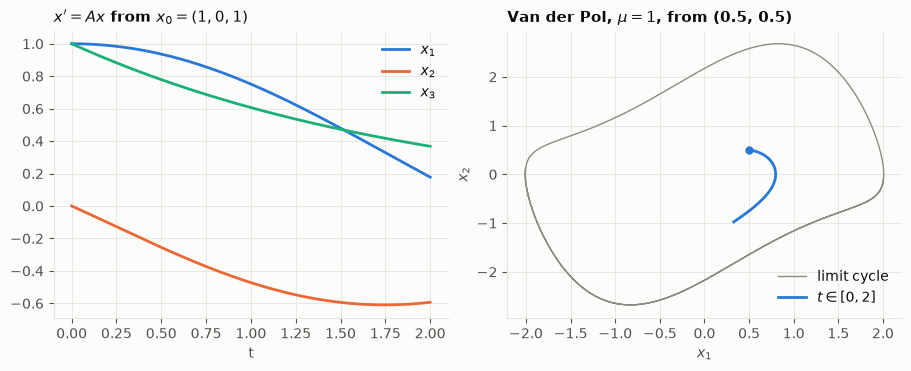

In [6]:
A = np.array([[0.0, 1.0, 0.0], [-1.0, -0.2, 0.5], [0.0, 0.0, -0.5]])
X0_LINEAR = np.array([1.0, 0.0, 1.0])
MU = 1.0
X0_VDP = np.array([0.5, 0.5])
T = 2.0


@sc.function(3, output="xdot", name="explicit_methods_linear")
def linear(x):
  return sc.const(A) @ x


@sc.function(2, output="xdot", name="explicit_methods_vdp")
def van_der_pol(x):
  return sc.stack([x[1], MU * (1 - x[0] * x[0]) * x[1] - x[0]])


def van_der_pol_np(t, x):
  return [x[1], MU * (1 - x[0] ** 2) * x[1] - x[0]]


exact_linear = expm(A * T) @ X0_LINEAR
exact_vdp = solve_ivp(van_der_pol_np, (0, T), X0_VDP, method="DOP853", rtol=1e-13, atol=1e-13).y[:, -1]

t = np.linspace(0, T, 200)
linear_path = np.stack([expm(A * s) @ X0_LINEAR for s in t])
vdp_path = solve_ivp(van_der_pol_np, (0, T), X0_VDP, method="DOP853", rtol=1e-10, atol=1e-10, t_eval=t).y
cycle = solve_ivp(van_der_pol_np, (0, 30), X0_VDP, method="DOP853", rtol=1e-10, atol=1e-10, t_eval=np.linspace(20, 30, 400)).y
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.6))
for i, color in enumerate((plotstyle.BLUE, plotstyle.ORANGE, plotstyle.AQUA)):
  ax1.plot(t, linear_path[:, i], color=color, label=f"$x_{i + 1}$")
ax1.set_xlabel("t")
ax1.set_title(r"$x' = Ax$ from $x_0 = (1, 0, 1)$")
ax1.legend()
ax2.plot(cycle[0], cycle[1], color=plotstyle.NEUTRAL, lw=1, label="limit cycle")
ax2.plot(vdp_path[0], vdp_path[1], color=plotstyle.BLUE, label=f"$t \\in [0, {T:g}]$")
ax2.plot(*X0_VDP, "o", color=plotstyle.BLUE)
ax2.set_xlabel("$x_1$")
ax2.set_ylabel("$x_2$")
ax2.set_title("Van der Pol, $\\mu = 1$, from (0.5, 0.5)")
ax2.legend(loc="lower right")
plt.show()

## Observed orders

After $n = T/h$ steps the global error is $e(h) = \lVert x_n - x(T) \rVert_\infty \approx C h^p$,
so $\log e = \log C + p \log h$ and the least-squares slope over a few step sizes estimates $p$.
Each method runs $n = n_0, 2n_0, 4n_0, 8n_0$ steps, with $n_0$ set by the declared order: 64 steps
for order 1, 32 for orders 2 and 3, 16 for orders 4 and 5. At the coarsest step the error must
already be $C h^p$, and at the finest it must stay well above rounding.

Each map is `si.explicit(model, method, dt=None)`, with inputs `x` and `dt`. It compiles on its
first call, so the 44 runs per problem use 11 compiled Functions and the steps run from Python.

In [7]:
FIRST_STEPS = {1: 64, 2: 32, 3: 32, 4: 16, 5: 16}
HALVINGS = 3


def global_errors(step, x0: np.ndarray, exact: np.ndarray, counts: np.ndarray) -> list[float]:
  """The error at ``T`` after ``n`` steps of ``step`` from ``x0``, for each ``n`` in ``counts``."""
  errors = []
  for n in counts:
    x, h = x0, np.array(T / n)
    for _ in range(n):
      x = step(x, h)
    errors.append(float(np.abs(x - exact).max()))
  return errors


def slope(counts: np.ndarray, errors: list[float]) -> float:
  return float(np.polyfit(np.log(T / counts), np.log(errors), 1)[0])


maps, methods = {}, {}
for method in [*explicit, HEUN3]:
  tab = si.tableau(method)
  counts = FIRST_STEPS[tab.order] * 2 ** np.arange(HALVINGS + 1)
  maps[tab.name] = (si.explicit(linear, method, dt=None), si.explicit(van_der_pol, method, dt=None))
  linear_errors = global_errors(maps[tab.name][0], X0_LINEAR, exact_linear, counts)
  vdp_errors = global_errors(maps[tab.name][1], X0_VDP, exact_vdp, counts)
  methods[tab.name] = {
    "stages": tab.stages,
    "declared": tab.order,
    "conditions": conditions[tab.name],
    "counts": counts,
    "linear_errors": linear_errors,
    "vdp_errors": vdp_errors,
    "linear_order": slope(counts, linear_errors),
    "vdp_order": slope(counts, vdp_errors),
  }

print(f"inputs of the maps: {maps['rk4'][1].input_names}, names {maps['rk4'][0].name} and {maps['heun3'][1].name}")
print(f"{'method':>9} {'stages':>6} {'order':>5} {'x = Ax':>7} {'finest error':>12} {'VdP':>6} {'finest error':>12}")
for name, row in methods.items():
  print(
    f"{name:>9} {row['stages']:>6} {row['declared']:>5} {row['linear_order']:>7.3f} {row['linear_errors'][-1]:>12.1e}"
    f" {row['vdp_order']:>6.3f} {row['vdp_errors'][-1]:>12.1e}"
  )

inputs of the maps: ('x', 'dt'), names explicit_methods_linear_rk4 and explicit_methods_vdp_heun3
   method stages order  x = Ax finest error    VdP finest error
    euler      1     1   1.009      1.9e-03  1.003      4.1e-03
     heun      2     2   2.006      9.7e-06  1.978      2.2e-05
 midpoint      2     2   2.006      9.7e-06  1.990      1.9e-05
  ralston      2     2   2.006      9.7e-06  1.986      2.0e-05
      rk3      3     3   3.012      1.9e-08  3.002      5.7e-08
   ssprk3      3     3   3.012      1.9e-08  3.002      4.3e-08
      rk4      4     4   4.023      4.7e-10  4.065      7.9e-10
     rk38      4     4   4.023      4.7e-10  4.034      8.7e-10
     bs32      4     3   3.012      1.9e-08  3.001      4.5e-08
   dopri5      7     5   5.068      2.1e-13  5.146      8.7e-13
    heun3      3     3   3.012      1.9e-08  3.006      3.7e-08


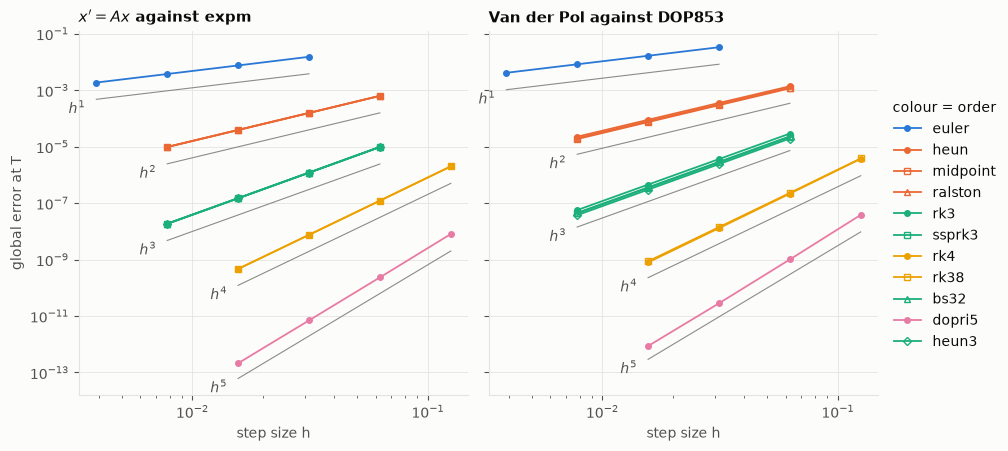

In [8]:
ORDER_COLORS = dict(zip(range(1, 6), plotstyle.SERIES, strict=False))
MARKERS = ["o", "s", "^", "D"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4), sharey=True)
for ax, key, title in zip(axes, ("linear_errors", "vdp_errors"), ("$x' = Ax$ against expm", "Van der Pol against DOP853"), strict=True):
  seen: dict[int, int] = {}
  for name, row in methods.items():
    p = row["declared"]
    k = seen[p] = seen.get(p, -1) + 1
    h = T / row["counts"]
    ax.loglog(h, row[key], MARKERS[k] + "-", color=ORDER_COLORS[p], lw=1.3, ms=4, mfc="none" if k else ORDER_COLORS[p], label=name)
    if k == 0:  # a reference slope h^p for each order, a little below the first method's line
      ax.loglog(h, 0.25 * row[key][0] * (h / h[0]) ** p, color=plotstyle.NEUTRAL, lw=0.8)
      ax.annotate(
        f"$h^{p}$", (h[-1], 0.25 * row[key][0] * (h[-1] / h[0]) ** p), xytext=(-20, -10), textcoords="offset points", color=plotstyle.TEXT_SECONDARY
      )
  ax.set_xlabel("step size h")
  ax.set_title(title)
axes[0].set_ylabel("global error at T")
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside right center", title="colour = order")
plt.show()

Every slope lands within 0.07 of the declared order, except DOPRI5 on Van der Pol, which reads
5.15. On the linear system the curves of one order lie on top of each other, as the stability
polynomials predict: heun, midpoint and ralston all end at $9.7 \times 10^{-6}$, the four
third-order methods at $1.9 \times 10^{-8}$, RK4 and the 3/8 rule at $4.7 \times 10^{-10}$. On Van
der Pol they separate, since the higher elementary differentials of a nonlinear $f$ weigh each
method's error coefficients differently. DOPRI5 ends at $2 \times 10^{-13}$ on the linear system and
$9 \times 10^{-13}$ on Van der Pol. The Van der Pol reference itself is good to about
$4 \times 10^{-14}$, the gap between DOP853 at $10^{-13}$ and at $2 \times 10^{-14}$, so the step
counts stop there.

### Why DOPRI5 reads high on Van der Pol

Dormand and Prince chose the coefficients to make the fifth-order error terms small. The
sixth-order terms are not minimized, so on many problems they lead over the whole range where the
error is above rounding. On the linear problem the leading error per step is
$(1/600 - 1/720)\, z^6 = z^6/3600$, and the next term, $z^7/5040$, is only $1.4/|h\lambda|$ times
smaller, so the slope there reads a little above 5. Started from $(2, 0)$ instead of $(0.5, 0.5)$,
the same compiled map shows the sixth-order terms leading on Van der Pol:

 steps  from (0.5, 0.5) local slope  from (2, 0) local slope
     4          4.3e-05         nan      4.3e-02         nan
     8          1.4e-06        4.92      3.2e-04        7.04
    16          3.8e-08        5.22      3.0e-06        6.76
    32          1.0e-09        5.24      3.2e-08        6.54
    64          2.8e-11        5.16      3.5e-10        6.54
   128          8.7e-13        5.03      2.8e-12        6.93


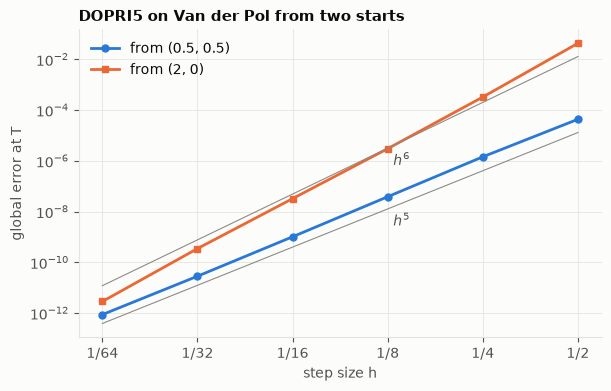

In [9]:
X0_FAR = np.array([2.0, 0.0])
exact_far = solve_ivp(van_der_pol_np, (0, T), X0_FAR, method="DOP853", rtol=1e-13, atol=1e-13).y[:, -1]
counts = 4 * 2 ** np.arange(6)
far_errors = global_errors(maps["dopri5"][1], X0_FAR, exact_far, counts)
near_errors = global_errors(maps["dopri5"][1], X0_VDP, exact_vdp, counts)
print(f"{'steps':>6} {'from (0.5, 0.5)':>16} {'local slope':>11} {'from (2, 0)':>12} {'local slope':>11}")
for i, n in enumerate(counts):
  local = [np.log2(e[i - 1] / e[i]) if i else np.nan for e in (near_errors, far_errors)]
  print(f"{n:>6} {near_errors[i]:>16.1e} {local[0]:>11.2f} {far_errors[i]:>12.1e} {local[1]:>11.2f}")

h = T / counts
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.loglog(h, near_errors, "o-", color=plotstyle.BLUE, label="from (0.5, 0.5)")
ax.loglog(h, far_errors, "s-", color=plotstyle.ORANGE, label="from (2, 0)")
for p, anchor in ((5, near_errors[0]), (6, far_errors[0])):
  ax.loglog(h, 0.3 * anchor * (h / h[0]) ** p, color=plotstyle.NEUTRAL, lw=0.8)
  ax.annotate(f"$h^{p}$", (h[2], 0.3 * anchor * (h[2] / h[0]) ** p), xytext=(4, -12), textcoords="offset points", color=plotstyle.TEXT_SECONDARY)
ax.set_xticks(h, [f"1/{round(1 / v)}" for v in h])
ax.minorticks_off()
ax.set_xlabel("step size h")
ax.set_ylabel("global error at T")
ax.set_title("DOPRI5 on Van der Pol from two starts")
ax.legend()
plt.show()

From $(2, 0)$ the local slopes stay between 6.5 and 7.0 all the way down to $3 \times 10^{-12}$,
below which rounding takes over. From $(0.5, 0.5)$ they sit between 4.9 and 5.3, and the fitted
slope over 16 to 128 steps is 5.15. The Checks below allow DOPRI5 0.3 on Van der Pol where the other
methods get 0.15.

## Checks

In [10]:
SAME_ORDER = (("heun", "midpoint", "ralston"), ("rk3", "ssprk3", "bs32", "heun3"), ("rk4", "rk38"))
assert set(methods) == {name for name, tab in si.TABLEAUS.items() if tab.explicit} | {"heun3"}
for name, row in methods.items():
  assert row["conditions"] == row["declared"], name
  assert abs(row["linear_order"] - row["declared"]) < 0.15, name
  # DOPRI5's fifth-order error constants are small by design; its slope reads a little high.
  assert abs(row["vdp_order"] - row["declared"]) < (0.3 if name == "dopri5" else 0.15), name
for same in SAME_ORDER:
  for name in same[1:]:  # on x' = Ax every method of one order is the same truncated exponential, up to rounding
    np.testing.assert_allclose(methods[name]["linear_errors"], methods[same[0]]["linear_errors"], rtol=1e-5)
assert embedded == {"bs32": 2, "dopri5": 4}
assert "only to order 3" in refusal
print(f"{1 + 3 * len(methods) + sum(len(same) - 1 for same in SAME_ORDER) + 2} checks passed")

42 checks passed


## The generated C

`si.rk4(van_der_pol, dt=0.05)` folds the interval into the code. The model is one `static inline`
function called four times, one call per stage, and the weights fold into
$x + \tfrac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)$ with $h/6 = 0.008\overline{3}$, as one would write it by
hand.

In [11]:
DT_C = 0.05
module = write_module(si.rk4(van_der_pol, dt=DT_C, name="explicit_methods_vdp_rk4_fixed"), GENERATED)
lines = module.source.splitlines()
print(f"{module.source_name}: {len(lines)} lines, {len(module.source) / 1e3:.1f} kB, in {GENERATED.relative_to(Path.cwd().parent.parent)}")
start = next(i for i, line in enumerate(lines) if line.startswith("static inline"))
end = max(i for i, line in enumerate(lines) if line.startswith("#ifdef __cplusplus"))
print("\n".join(line for line in lines[start:end] if line.strip()))

explicit_methods_vdp_rk4_fixed.c: 60 lines, 1.8 kB, in examples/generated/integrators/explicit_methods
static inline void explicit_methods_vdp_raw(const double* x, double* xdot, double* w) {
  (void)w;
  double v0 = x[1];
  double v1 = x[0];
  *(double2*)(xdot) = (double2){v0, (((1.0 - (v1 * v1)) * v0) - v1)};
}
int explicit_methods_vdp_rk4_fixed(const double** arg, double** res, int* iw, double* w, int mem) {
  (void)iw;
  (void)mem;
  if (!arg || !res) return SCALY_ERR_NULL_ABI;
  (void)w;
  if (!arg[0]) return SCALY_ERR_NULL_INPUT;
  if (!res[0]) return SCALY_ERR_NULL_RESULT;
  double s0[2];
  double s1[2];
  double s2[2];
  double s3[2];
  double s4[2];
  double s5[2];
  double s6[2];
  explicit_methods_vdp_raw(arg[0], s0, NULL);
  for (long long i_t5 = 0; i_t5 < 2; ++i_t5) {
    s1[i_t5] = (arg[0][i_t5] + (0.025000000000000001 * s0[i_t5]));
  }
  explicit_methods_vdp_raw(s1, s2, NULL);
  for (long long i_t10 = 0; i_t10 < 2; ++i_t10) {
    s3[i_t10] = (arg[0][i_t10] + (0.0250000000